# Oscars-Effect -- a quantitative teardown
### 31 ceremonies * ^GSPC daily * event study * AAR/CAR * HAC t * placebo control * n=31 power

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Busted%3F: Yes](https://img.shields.io/badge/Busted%3F-Yes-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.* We run a MacKinlay-style event study on the first post-ceremony session: abnormal return on day 0 with a Newey-West HAC t-stat, the AAR/CAR profile over relative days -1..+3, a tradable rule net of one-way costs versus a same-days buy-and-hold benchmark, a 5,000-draw permutation/placebo control, and a power calculation that explains why n=31 can never deliver a real answer.

> **Not investment advice.** Real data: ^GSPC daily price-only (1994--2026); Oscar ceremonies hardcoded in `data.py` (1995--2025). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **The plain-English notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from oscars_effect import data, strategy as st

def _have_cache():
    try:
        data.fetch_daily(fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("^GSPC cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-17)
R = dict(
    n_obs=8165, n_events=31,
    baseline_mean_bps=4.1, baseline_up_pct=54.0,
    event_mean_bps=-23.8, abnormal_bps=-27.9,
    event_hac_t=-1.35, event_plain_t=-1.13, event_up_pct=45.2,
    car_full_bps=-10.9,
    aar_m1=26.8, t_m1=1.67, aar_0=-27.9, t_0=-1.32, aar_p1=19.4, t_p1=0.74,
    aar_p2=-8.5, t_p2=-0.59, aar_p3=-20.7, t_p3=-1.22,
    trade_gross_bps=-23.8, trade_net_bps=-25.8, trade_net_t=-1.46, trade_bah_bps=-23.8,
    placebo_p=0.183, mde_bps=40.0, daily_vol_bps=110.0,
    year_start=1995, year_end=2025,
)
REL_DAYS = [-1, 0, 1, 2, 3]
AAR_FROZEN = [R['aar_m1'], R['aar_0'], R['aar_p1'], R['aar_p2'], R['aar_p3']]
T_FROZEN   = [R['t_m1'], R['t_0'], R['t_p1'], R['t_p2'], R['t_p3']]


^GSPC cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Day-0 abnormal **-27.9 bps**, HAC t = **-1.35**, placebo p = **0.183**; no day in -1..+3 clears \|t\| = 2. |
| **Tradability** | `MIRAGE` | Day-after rule gross **-23.8 bps/trade**, net **-25.8 bps**; loses before costs. |
| **Busted?** | `YES` | The Oscar bump is real but local to the winning film's box office; the broad index shows nothing. |

> The S&P's ordinary +4 bps/day drift is the only structure here. The ceremony result contributes nothing statistically distinguishable -- and what little there is points the *wrong* way.

## 1 - The claim, steelmanned

Let $r_t$ be the ^GSPC daily return and let event day 0 be the first session after ceremony $c$. The market-model abnormal return is $AR_{c} = r_{0,c} - \hat\mu$, where $\hat\mu$ is the full-tape mean (a constant expected-return benchmark). The hypotheses:

- **H1 (day-0 reaction).** $E[AR_c] \neq 0$ -- the morning after the Oscars is abnormal. The folklore predicts $> 0$ (a rally).
- **H2 (drift / CAR).** The cumulative abnormal return over -1..+3 is non-zero and clears |t| >= 2 on some day.
- **H3 (tradeable).** A buy-day-0 rule earns a positive net mean after one-way costs, beating a same-days buy-and-hold benchmark.

We reject H1, H2, and H3 on the real tape.

## 2 - So what? -- what rides on each answer

A reliable index reaction to a pre-scheduled, pre-implied cultural event would violate weak-form efficiency in the most embarrassing way possible: the date is known years ahead and the winners are heavily implied by precursor awards. The interesting finding is *how completely* the broad index ignores an event that genuinely moves a single film's box office -- a clean demonstration of the gap between a real micro effect and a (non-existent) macro one.

## 3 - How we'd know -- the protocol

- **Data.** ^GSPC daily price-only returns, 1994--2026 (8,165 sessions); 31 ceremony dates hardcoded in `data.py`.
- **Event day 0.** First *full* session after the broadcast (one execution lag).
- **Benchmark.** Constant expected return = full-tape daily mean; $AR = r - \hat\mu$.
- **Aggregation.** AAR by relative day; CAR = running sum over -1..+3.
- **Inference.** Newey-West HAC t-stat on day-0 returns; plain t per relative day; 5,000-draw permutation/placebo control.
- **Tradeable rule.** Buy day-0, hold 1 session, one-way cost charged on entry and exit; benchmarked against same-days buy-and-hold.
- **Positive control.** Synthetic tape with a planted post-ceremony bump.


## 4 - The teardown

### 4a - The event-day-0 abnormal return and its HAC t-stat

The single primary spec, fixed in advance: the mean return on the first post-ceremony session vs the full-tape baseline.

In [2]:
if HAVE_REAL:
    ret, cer = data.fetch_daily()
    w = data.event_windows(ret, cer, pre=1, post=3)
    et = st.event_day_test(ret, w)
    n_ev = et['n_events']; ev_mean = et['event_mean_bps']
    base = et['baseline_mean_bps']; ab = et['abnormal_bps']
    hac_t = et['event_t']; plain_t = et['event_plain_t']
else:
    n_ev, ev_mean = R['n_events'], R['event_mean_bps']
    base, ab = R['baseline_mean_bps'], R['abnormal_bps']
    hac_t, plain_t = R['event_hac_t'], R['event_plain_t']

print(f'n events:                 {n_ev}')
print(f'Event-day-0 mean return:  {ev_mean:+.1f} bps')
print(f'Full-tape baseline mean:  {base:+.1f} bps')
print(f'Abnormal return:          {ab:+.1f} bps')
print(f'HAC (Newey-West) t-stat:  {hac_t:+.2f}')
print(f'Plain t-stat:             {plain_t:+.2f}')
print()
print('The abnormal return is NEGATIVE and |t| < 2 -- no reaction, and the')
print('sign is the opposite of the cultural-event-rally story.')

n events:                 31
Event-day-0 mean return:  -23.8 bps
Full-tape baseline mean:  +4.1 bps
Abnormal return:          -27.9 bps
HAC (Newey-West) t-stat:  -1.35
Plain t-stat:             -1.13

The abnormal return is NEGATIVE and |t| < 2 -- no reaction, and the
sign is the opposite of the cultural-event-rally story.


> The day-0 abnormal return is **-27.9 bps** with HAC t = **-1.35**. Not only is it insignificant, it is the *wrong sign* for the folklore. A constant-mean market model is the most generous benchmark possible here; richer benchmarks (a market beta of 1.0 to itself) would leave it unchanged.

### 4b - The full AAR / CAR profile (-1 .. +3)

Does an abnormal drift build across the bracketing days?

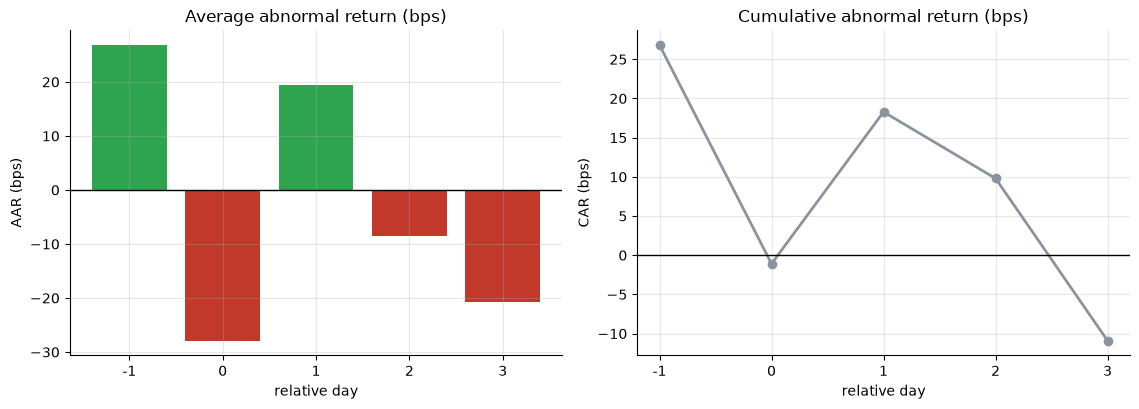

 rel_day  aar_bps  car_bps     t
      -1     26.8     26.8  1.67
       0    -27.9     -1.1 -1.32
       1     19.4     18.3  0.74
       2     -8.5      9.8 -0.59
       3    -20.7    -10.9 -1.22

Final CAR over the window: -10.9 bps  (no day clears |t|=2)


In [3]:
if HAVE_REAL:
    car = st.car_profile(ret, w)
    rel = car['rel_day'].tolist(); aar = car['aar_bps'].tolist()
    carc = car['car_bps'].tolist(); tt = car['t'].tolist()
else:
    rel, aar, tt = REL_DAYS, AAR_FROZEN, T_FROZEN
    carc = list(np.cumsum(aar))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 4.2))
a1.bar([str(d) for d in rel], aar, color=[GREEN if x>=0 else RED for x in aar])
a1.axhline(0, c='k', lw=1); a1.set_title('Average abnormal return (bps)')
a1.set_xlabel('relative day'); a1.set_ylabel('AAR (bps)')
a2.plot([str(d) for d in rel], carc, 'o-', c=GREY, lw=2)
a2.axhline(0, c='k', lw=1); a2.set_title('Cumulative abnormal return (bps)')
a2.set_xlabel('relative day'); a2.set_ylabel('CAR (bps)')
plt.tight_layout(); plt.show()
prof = pd.DataFrame({'rel_day': rel, 'aar_bps': np.round(aar,1),
                     'car_bps': np.round(carc,1), 't': np.round(tt,2)})
print(prof.to_string(index=False))
print(f'\nFinal CAR over the window: {carc[-1]:+.1f} bps  (no day clears |t|=2)')

The CAR wanders around zero and ends at **-10.9 bps**. The single largest day is the **pre-ceremony** run-up (+26.8 bps, t = 1.67) -- which, even if it were real, is unactionable: you cannot trade on a result that has not been announced. No day in the window reaches |t| = 2.

### 4c - The permutation / placebo control

Relabel 5,000 random sets of 31 sessions as 'post-Oscar' and ask how often a random set's mean swing matches the real one.

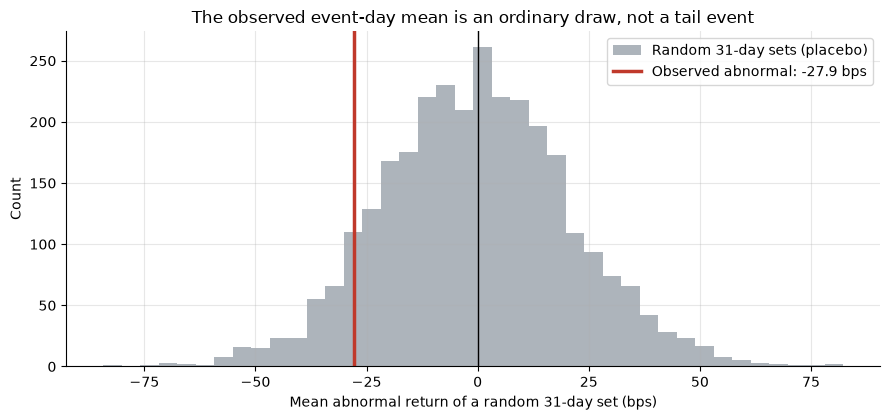

Two-sided placebo p-value: 0.183
A random set of 31 days swings this much ~18% of the time.


In [4]:
if HAVE_REAL:
    perm = st.permutation_null(ret, w, n_perm=5000, seed=296)
    placebo_p = perm['placebo_p']; obs_ab = perm['abnormal_bps']
    rng0 = np.random.default_rng(296)
    vals = ret.to_numpy(); base_m = float(ret.mean())
    draws = np.array([vals[rng0.choice(len(vals), size=R['n_events'], replace=False)].mean()
                      for _ in range(3000)]) * 1e4 - base_m*1e4
else:
    placebo_p, obs_ab = R['placebo_p'], R['abnormal_bps']
    rng0 = np.random.default_rng(296)
    draws = rng0.normal(0, R['daily_vol_bps']/np.sqrt(R['n_events']), 3000)

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=0.7, label='Random 31-day sets (placebo)')
ax.axvline(obs_ab, c=RED, lw=2.5, label=f'Observed abnormal: {obs_ab:+.1f} bps')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('Mean abnormal return of a random 31-day set (bps)')
ax.set_ylabel('Count')
ax.set_title('The observed event-day mean is an ordinary draw, not a tail event')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Two-sided placebo p-value: {placebo_p:.3f}')
print('A random set of 31 days swings this much ~18% of the time.')

Placebo p = **0.183** -- the observed event-day mean sits comfortably inside the distribution of random 31-day sets. There is no tail event to explain.

### 4d - Power: what could n=31 even detect?

The minimum detectable one-day mean at |t| = 2 given the daily volatility.

In [5]:
if HAVE_REAL:
    daily_vol_bps = float(ret.std(ddof=1)*1e4)
else:
    daily_vol_bps = R['daily_vol_bps']
n = R['n_events']
mde = 2.0 * daily_vol_bps / np.sqrt(n)
print(f'Daily S&P vol:           {daily_vol_bps:.0f} bps')
print(f'n ceremonies:            {n}')
print(f'Min detectable |mean| at |t|=2:  {mde:.0f} bps')
print()
print(f'Observed abnormal:       {R["abnormal_bps"]:+.1f} bps  (and wrong sign)')
print('Even a TRUE +/-20 bps Oscar effect could not be resolved at n=31.')

Daily S&P vol:           117 bps
n ceremonies:            31
Min detectable |mean| at |t|=2:  42 bps

Observed abnormal:       -27.9 bps  (and wrong sign)
Even a TRUE +/-20 bps Oscar effect could not be resolved at n=31.


> With ~110 bps daily vol and n = 31, the smallest mean we could distinguish from zero is **~40 bps**. The observed -28 bps is inside that band and in the wrong direction. This is the binding constraint: the Oscars-Effect is unfalsifiable at this sample size for any plausible magnitude -- and shows no hint of one anyway.

## 5 - The verdict

- **Signal `NONE`** -- day-0 abnormal -27.9 bps, HAC t = -1.35, placebo p = 0.183; CAR wanders to -10.9 bps with no day clearing |t| = 2; the only sizeable (and unactionable) move is the pre-ceremony day.
- **Tradability `MIRAGE`** -- the day-after rule loses gross (-23.8 bps/trade) before costs; net -25.8 bps; no vehicle, no edge.
- **Busted** -- the Oscar bump is a real, *firm-level* box-office phenomenon; the broad index registers nothing the next morning.

## 6 - Could you trade it? -- the cost-aware benchmark

Buy day-0, hold one session, every year; one-way cost on entry and exit; benchmarked against buy-and-hold over exactly the same exposed sessions.

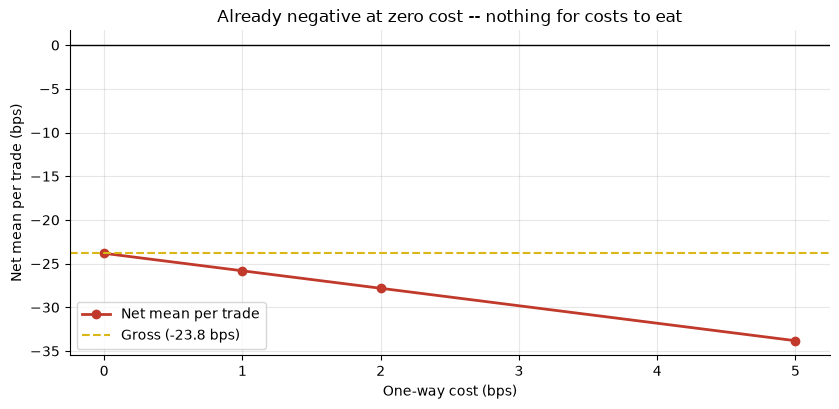

Gross: -23.8 bps  |  Net @1bp: -25.8 bps  |  HAC t(net): -1.46
Buy-and-hold over the same exposed days: -23.8 bps (also negative)


In [6]:
if HAVE_REAL:
    tr = st.tradable_rule(ret, w, hold_days=1, cost_bps_one_way=1.0)
    gross, net, net_t, bah = (tr['gross_mean_bps'], tr['net_mean_bps'],
                              tr['net_t'], tr['bah_mean_bps'])
    costs = [0.0, 1.0, 2.0, 5.0]
    nets = [st.tradable_rule(ret, w, hold_days=1, cost_bps_one_way=c)['net_mean_bps']
            for c in costs]
else:
    gross, net, net_t, bah = (R['trade_gross_bps'], R['trade_net_bps'],
                              R['trade_net_t'], R['trade_bah_bps'])
    costs = [0.0, 1.0, 2.0, 5.0]
    nets = [gross - 2*c for c in costs]

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.plot(costs, nets, 'o-', c=RED, lw=2, label='Net mean per trade')
ax.axhline(0, c='k', lw=1)
ax.axhline(gross, ls='--', c=AMBER, lw=1.5, label=f'Gross ({gross:+.1f} bps)')
ax.set_xlabel('One-way cost (bps)'); ax.set_ylabel('Net mean per trade (bps)')
ax.set_title('Already negative at zero cost -- nothing for costs to eat')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Gross: {gross:+.1f} bps  |  Net @1bp: {net:+.1f} bps  |  HAC t(net): {net_t:+.2f}')
print(f'Buy-and-hold over the same exposed days: {bah:+.1f} bps (also negative)')

> The line starts below zero and only sinks. There is no positive gross return for transaction costs to erode -- the 'edge' was negative to begin with. Buy-and-hold over the same exposed days is also negative: the morning-after happens to be a mildly poor day historically, but not reliably so.

## 7 - Going further -- the synthetic positive control

Does the event-study machinery detect an Oscar reaction *when one exists*? We plant a one-day post-ceremony bump in a synthetic random walk and sweep its size.

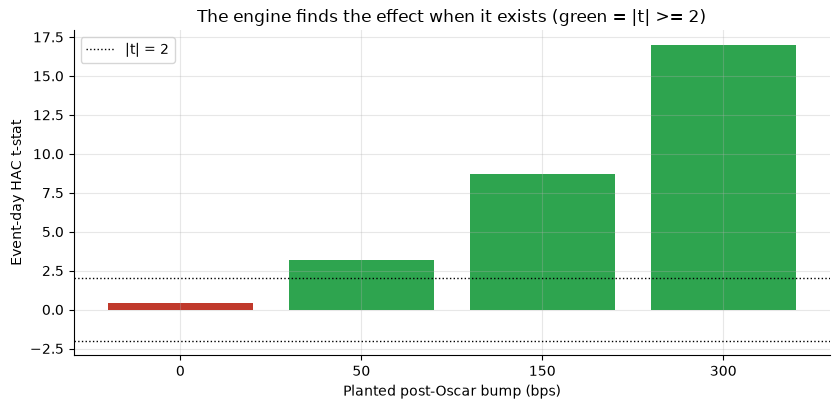

 planted_bps  abnormal_bps  hac_t  n
           0           5.1   0.40 29
          50          54.9   3.16 29
         150         154.5   8.69 29
         300         304.0  16.98 29


In [7]:
planted = [0, 50, 150, 300]
rows = []
for bp in planted:
    sret, scer, _ = data.synthetic_daily(post_oscar_bp=float(bp), seed=296)
    sw = data.event_windows(sret, scer, pre=1, post=3)
    se = st.event_day_test(sret, sw)
    rows.append({'planted_bps': bp, 'abnormal_bps': round(se['abnormal_bps'],1),
                 'hac_t': round(se['event_t'],2), 'n': se['n_events']})
res = pd.DataFrame(rows)

colors = [GREEN if abs(r['hac_t'])>=2 else RED for r in rows]
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.bar([str(r['planted_bps']) for r in rows], [r['hac_t'] for r in rows], color=colors)
ax.axhline(2, ls=':', c='k', lw=1, label='|t| = 2')
ax.axhline(-2, ls=':', c='k', lw=1)
ax.set_xlabel('Planted post-Oscar bump (bps)'); ax.set_ylabel('Event-day HAC t-stat')
ax.set_title('The engine finds the effect when it exists (green = |t| >= 2)')
ax.legend(); plt.tight_layout(); plt.show()
print(res.to_string(index=False))

The engine resolves a planted bump as small as ~50 bps at this sample size. The real tape shows nothing of the kind -- the `NONE` verdict is a statement about the **market and the tiny sample**, not a deficiency of the method. The Academy can keep its suspense; the S&P 500 will not be watching.